#### Ferramentas globais

In [1]:
# Atualizar plotly para geração de gráficos dinâmicos
!pip install plotly --upgrade

In [3]:
import pandas as pd # Analysis / Manipulation tools
import numpy as np # statistical / Mathematical
import seaborn as sns # data visualization based on matplotlib
import matplotlib.pyplot as plt # data visualization
import plotly.express as px # dynamic plots

In [6]:
titanic_train = pd.read_csv('datas/train.csv')

### Data Exploration

In [7]:
titanic_train.shape

(891, 12)

In [10]:
titanic_train.head()
"""
    Survival ( 0 = No, 1 = Yes)
    Pclass ( 1 = 1st, 2 = 2st, 3 = 3st)
    sibsp (Sibling = brother, sister, stepbrother, stersister -- Spouse = husband, wife)
    parch (Parent = mother, father -- Child = daughter, son, stepdaughter, stepson. Viajando com babá == 0)
    embarked (port of embarkation) C = Cherbourg, Q = Queenstown, S = Southampton
"""

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
titanic_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Data Visualization

In [18]:
def func_unique(variables_param):
    return np.unique(titanic_train[variables_param], return_counts=True) # verificando se há valores únicos

In [22]:
func_unique('Survived')

(array([0, 1]), array([549, 342]))

In [21]:
func_unique('Pclass')

(array([1, 2, 3]), array([216, 184, 491]))

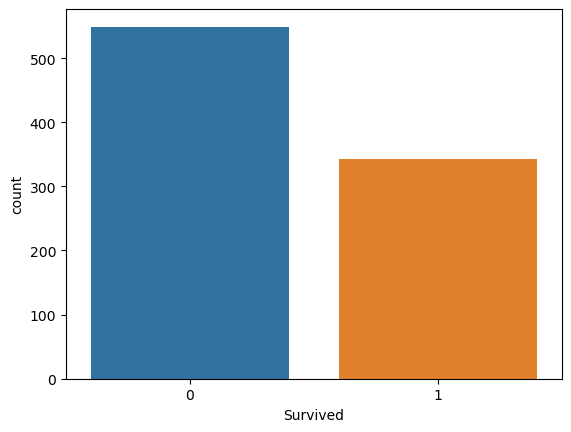

In [25]:
# Relação de quantos morreram e quantos não morreram
sns.countplot(titanic_train, x = titanic_train['Survived']);

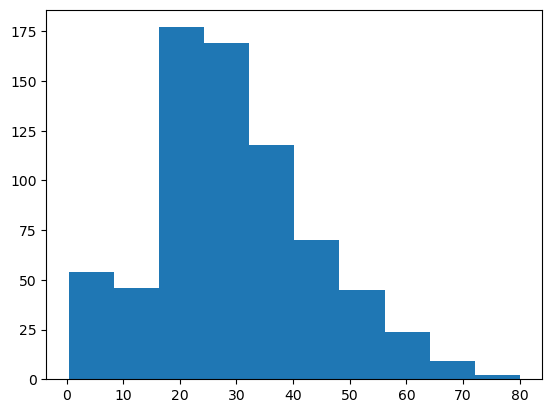

In [37]:
plt.hist(x = titanic_train['Age']); # Checando faixa etária presente no navio

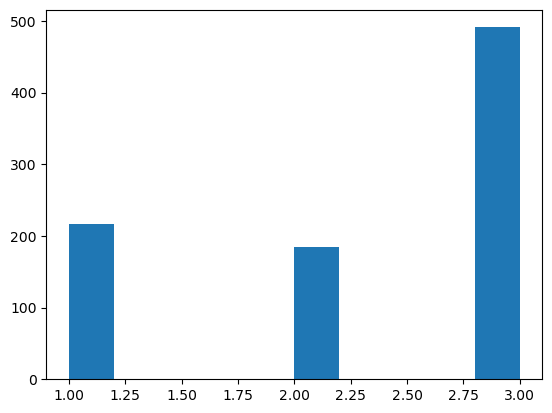

In [39]:
plt.hist(x = titanic_train['Pclass']); # Checando as classes que predominam 

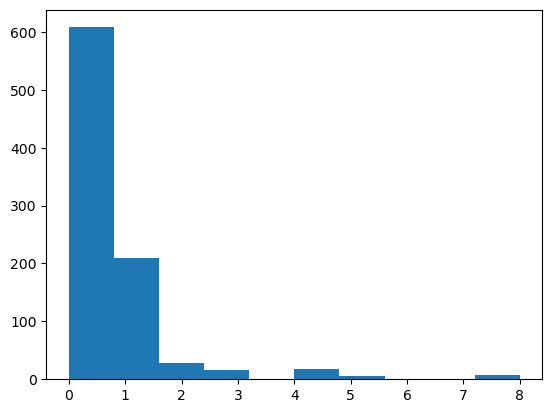

In [45]:
plt.hist(x = titanic_train['SibSp']); # checando quantos membros da família foram levadas

(array([732., 106.,  31.,   2.,  11.,   6.,   0.,   0.,   0.,   3.]),
 array([  0.     ,  51.23292, 102.46584, 153.69876, 204.93168, 256.1646 ,
        307.39752, 358.63044, 409.86336, 461.09628, 512.3292 ]),
 <BarContainer object of 10 artists>)

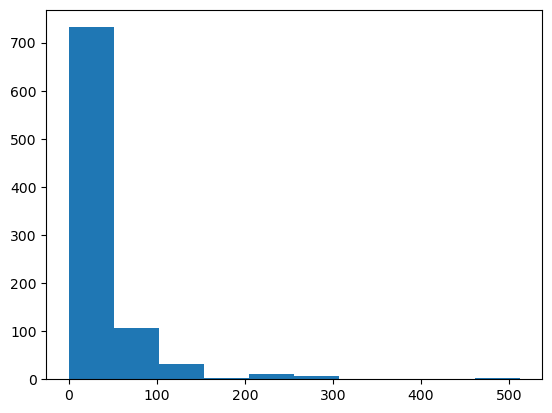

In [46]:
plt.hist(x = titanic_train['Fare']); # checando a tarifa que predominou

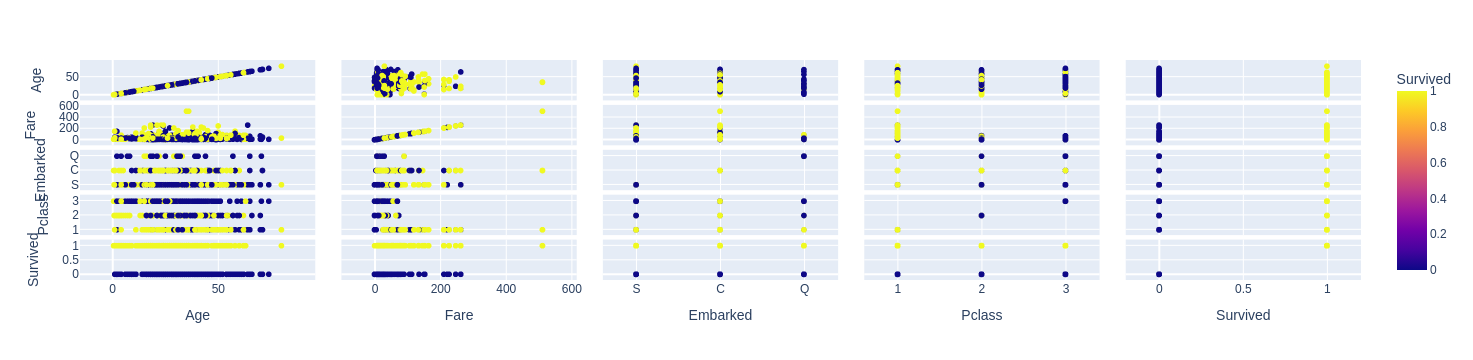

In [56]:
# gráfico dinâmico
plot_dynamic = px.scatter_matrix(titanic_train,
                                dimensions=['Age', 'Fare', 'Embarked', 'Pclass', 'Survived'],
                                color='Survived')
plot_dynamic.show()

### Missing values

In [58]:
titanic_train.isnull().sum() # VERIFICANDO VALORES FALTANTES

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [67]:
# Analisando os passageiros que tem a idade nula
titanic_train.loc[titanic_train['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [68]:
titanic_train['Age'].mean() # fazendo a média para corrigir os erros de valores faltantes

29.69911764705882

In [69]:
# fazendo preechimento de forma automática
titanic_train['Age'].fillna(titanic_train['Age'].mean(), inplace=True) # inplace deve está ativado para alteração no dataframe

In [72]:
titanic_train['Age'].isnull().sum()

0

In [82]:
titanic_train.loc[[5, 17, 19, 26, 28]] # idade preenchida com sucesso

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,29.699118,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,29.699118,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,29.699118,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,29.699118,0,0,330959,7.8792,NaN,Q


In [89]:
titanic_train.loc[titanic_train['Cabin'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.000000,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.000000,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S


In [90]:
titanic_train['Cabin'].fillna('Unknown', inplace=True) # Cabines com NaN foi passada para Unknown, pois não se sabe qual cabine o passageiro está

In [91]:
titanic_train.loc[[0, 2, 4, 5, 7]]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,Unknown,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,Unknown,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,Unknown,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Unknown,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,Unknown,S


In [93]:
titanic_train.loc[titanic_train['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [94]:
titanic_train['Embarked'].fillna('Unknown', inplace=True) # embarcação NaN foi editada para Unknown, já que é desconhecido enão possui valor válido

In [101]:
titanic_train.loc[titanic_train['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [103]:
titanic_train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

### Incosistent values

In [98]:
titanic_train.loc[titanic_train['Pclass'] < 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [99]:
titanic_train.loc[titanic_train['Survived'] < 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [100]:
titanic_train.loc[titanic_train['Age'] < 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


### Predictors and Classes

In [118]:
"""
    x = previsores
    y = classes
"""
x_titanic_train = titanic_train.iloc[:, 2:13].values
y_titanic_train = titanic_train.iloc[:, 1].values

In [121]:
x_titanic_train

array([[3, 'Braund, Mr. Owen Harris', 'male', ..., 7.25, 'Unknown', 'S'],
       [1, 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
        'female', ..., 71.2833, 'C85', 'C'],
       [3, 'Heikkinen, Miss. Laina', 'female', ..., 7.925, 'Unknown',
        'S'],
       ...,
       [3, 'Johnston, Miss. Catherine Helen "Carrie"', 'female', ...,
        23.45, 'Unknown', 'S'],
       [1, 'Behr, Mr. Karl Howell', 'male', ..., 30.0, 'C148', 'C'],
       [3, 'Dooley, Mr. Patrick', 'male', ..., 7.75, 'Unknown', 'Q']],
      dtype=object)

In [122]:
y_titanic_train

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,